In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [15]:
customers = pd.read_csv("../data/processed/customers_clean.csv")
products = pd.read_csv("../data/processed/products_clean.csv")
sales = pd.read_csv("../data/processed/sales_clean.csv")

customer_segments = pd.read_csv(
    "../data/processed/customer_segments.csv"
)

In [16]:
products.columns


Index(['product_id', 'product_name', 'category', 'price', 'brand'], dtype='object')

In [17]:
customers.columns


Index(['customer_id', 'name', 'age', 'gender', 'location', 'join_date',
       'total_spent'],
      dtype='object')

In [18]:

sales.columns


Index(['sale_id', 'product_id', 'customer_id', 'date', 'quantity',
       'sale_price', 'channel'],
      dtype='object')

In [19]:

customer_segments.columns

Index(['customer_id', 'segment'], dtype='object')

In [20]:
print("Customers :", customers.shape)
print("Products :", products.shape)
print("Sales :", sales.shape)
print("Customer segments :", customer_segments.shape)

Customers : (7000, 7)
Products : (200, 5)
Sales : (30000, 7)
Customer segments : (7000, 2)


In [21]:
customer_segments.head()

,customer_id,segment
0,2001,0
1,2002,2
2,2003,2
3,2004,0
4,2005,2


In [22]:
customer_data = customers.merge(
    customer_segments,
    on="customer_id",
    how="left"
)
customer_data

,customer_id,name,age,gender,location,join_date,total_spent,segment
0,2001,Customer_2001,33,Female,New York,2021-12-13,0.00,0
1,2002,Customer_2002,59,Male,New York,2023-03-08,1103.79,2
2,2003,Customer_2003,51,Male,Houston,2021-04-29,1172.71,2
3,2004,Customer_2004,18,Male,Houston,2022-06-04,43.91,0
4,2005,Customer_2005,39,Female,Los Angeles,2023-01-03,1264.34,2
...,...,...,...,...,...,...,...,...
6995,8996,Customer_8996,49,Male,Los Angeles,2023-11-10,492.34,2
6996,8997,Customer_8997,33,Male,Phoenix,2021-05-12,647.97,2
6997,8998,Customer_8998,18,Male,Chicago,2021-08-11,291.97,0
6998,8999,Customer_8999,27,Female,Los Angeles,2022-03-12,158.38,0


In [23]:
print("Nombre de clients :", len(customer_data))
print("Valeurs manquantes dans segment :")
print(customer_data["segment"].isnull().sum())

Nombre de clients : 7000
Valeurs manquantes dans segment :
0


In [24]:
#taille des segment

segment_counts = customer_data["segment"].value_counts().sort_index()

segment_counts

segment
0    2962
1    1008
2    3030
Name: count, dtype: int64

In [25]:
# Calcul du montant de chaque achat
sales["purchase_amount"] = (
    sales["quantity"] * sales["sale_price"]
)

# Calcul des indicateurs d'achat par client
customer_sales = sales.groupby("customer_id").agg(
    purchase_frequency=("sale_id", "count"),
    total_quantity=("quantity", "sum"),
    sales_amount=("purchase_amount", "sum"),
    average_basket=("purchase_amount", "mean")
).reset_index()

customer_sales.head()

,customer_id,purchase_frequency,total_quantity,sales_amount,average_basket
0,2002,5,9,1103.79,220.758000
1,2003,6,13,1172.71,195.451667
2,2004,1,1,43.91,43.910000
3,2005,7,16,1264.34,180.620000
4,2006,3,6,391.55,130.516667


In [26]:
customer_data = customer_data.merge(
    customer_sales,
    on="customer_id",
    how="left"
)

customer_data[
    [
        "purchase_frequency",
        "total_quantity",
        "sales_amount",
        "average_basket"
    ]
] = customer_data[
    [
        "purchase_frequency",
        "total_quantity",
        "sales_amount",
        "average_basket"
    ]
].fillna(0)

In [27]:
sales_products = sales.merge(
    products[["product_id", "category"]],
    on="product_id",
    how="left"
)

In [28]:
sales_products.head()

,sale_id,product_id,customer_id,date,quantity,sale_price,channel,purchase_amount,category
0,1,204,5647,2024-01-30,2,172.62,Online,345.24,Sports & Travel
1,2,150,6294,2024-04-12,1,58.93,Online,58.93,Health & Beauty
2,3,229,8549,2024-01-16,3,21.12,In-Store,63.36,Home
3,4,162,7331,2024-02-10,4,37.58,Online,150.32,Lifestyle
4,5,104,2926,2024-09-11,1,37.95,Online,37.95,Electronic Accessories


In [29]:
sales_segments = sales_products.merge(
    customer_segments,
    on="customer_id",
    how="left"
)

sales_segments.head()

,sale_id,product_id,customer_id,date,quantity,sale_price,channel,purchase_amount,category,segment
0,1,204,5647,2024-01-30,2,172.62,Online,345.24,Sports & Travel,1
1,2,150,6294,2024-04-12,1,58.93,Online,58.93,Health & Beauty,2
2,3,229,8549,2024-01-16,3,21.12,In-Store,63.36,Home,0
3,4,162,7331,2024-02-10,4,37.58,Online,150.32,Lifestyle,0
4,5,104,2926,2024-09-11,1,37.95,Online,37.95,Electronic Accessories,2


In [30]:
preferences = (
    sales_segments
    .groupby(["segment", "category"])["quantity"]
    .sum()
    .reset_index()
)

preferences

,segment,category,quantity
0,0,Electronic Accessories,1168
1,0,Health & Beauty,1670
2,0,Home,1809
3,0,Lifestyle,2307
4,0,Sports & Travel,955
5,1,Electronic Accessories,3563
6,1,Health & Beauty,4146
7,1,Home,5998
8,1,Lifestyle,5853
9,1,Sports & Travel,3008


In [31]:
preferences["proportion"] = (
    preferences["quantity"]
    / preferences.groupby("segment")["quantity"].transform("sum")
    * 100
)

preferences["proportion"] = preferences["proportion"].round(2)

preferences

,segment,category,quantity,proportion
0,0,Electronic Accessories,1168,14.77
1,0,Health & Beauty,1670,21.12
2,0,Home,1809,22.87
3,0,Lifestyle,2307,29.17
4,0,Sports & Travel,955,12.07
5,1,Electronic Accessories,3563,15.79
6,1,Health & Beauty,4146,18.37
7,1,Home,5998,26.58
8,1,Lifestyle,5853,25.93
9,1,Sports & Travel,3008,13.33


In [32]:
preferences.loc[
    preferences.groupby("segment")["proportion"].idxmax()
]

,segment,category,quantity,proportion
3,0,Lifestyle,2307,29.17
7,1,Home,5998,26.58
12,2,Home,7713,28.05


In [33]:
preference_table = preferences.pivot(
    index="category",
    columns="segment",
    values="proportion"
)

preference_table.round(2)

segment,0,1,2
category,,,
Electronic Accessories,14.77,15.79,15.27
Health & Beauty,21.12,18.37,17.15
Home,22.87,26.58,28.05
Lifestyle,29.17,25.93,25.62
Sports & Travel,12.07,13.33,13.91


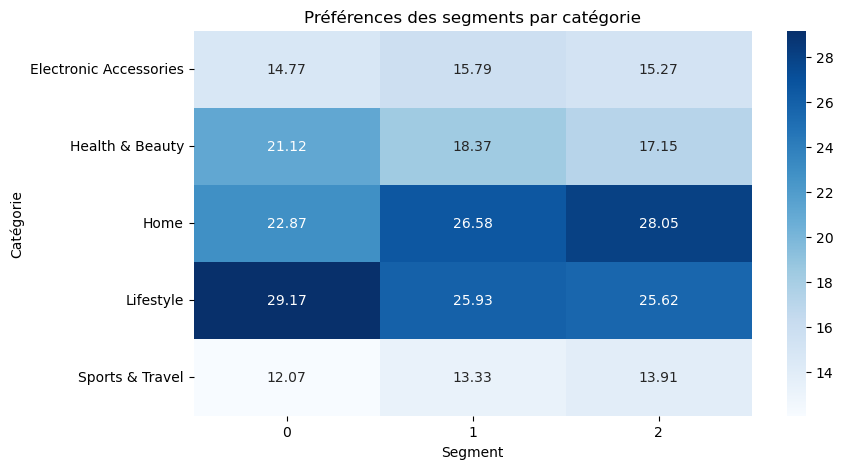

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

sns.heatmap(
    preference_table,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Préférences des segments par catégorie")
plt.xlabel("Segment")
plt.ylabel("Catégorie")
plt.show()

In [35]:
categorie_dominante = (
    preferences.loc[
        preferences.groupby("segment")["proportion"].idxmax(),
        ["segment", "category", "proportion"]
    ]
    .rename(columns={
        "category": "categorie_dominante",
        "proportion": "part_categorie"
    })
)

categorie_dominante

,segment,categorie_dominante,part_categorie
3,0,Lifestyle,29.17
7,1,Home,26.58
12,2,Home,28.05


In [36]:
# Sauvegarder le résultat de la segmentation

categorie_dominante_2 = categorie_dominante.copy()

categorie_dominante_2.to_csv(
    "../data/processed/categorie_dominante_2.csv",
    index=False
)

In [37]:
cluster_profiles = (
    customer_data
    .groupby("segment")[
        [
            "age",
            "total_spent",
            "purchase_frequency",
            "total_quantity",
            "average_basket"
        ]
    ]
    .mean()
    .reset_index()
)

cluster_profiles

,segment,age,total_spent,purchase_frequency,total_quantity,average_basket
0,0,35.524646,166.305648,1.742404,2.670155,74.783075
1,1,35.326389,1881.721339,11.029762,22.388889,175.046353
2,2,35.576898,787.251241,4.528383,9.074257,199.871597


In [38]:
profil_final = cluster_profiles.merge(
    categorie_dominante,
    on="segment",
    how="left"
)

profil_final

,segment,age,total_spent,purchase_frequency,total_quantity,average_basket,categorie_dominante,part_categorie
0,0,35.524646,166.305648,1.742404,2.670155,74.783075,Lifestyle,29.17
1,1,35.326389,1881.721339,11.029762,22.388889,175.046353,Home,26.58
2,2,35.576898,787.251241,4.528383,9.074257,199.871597,Home,28.05


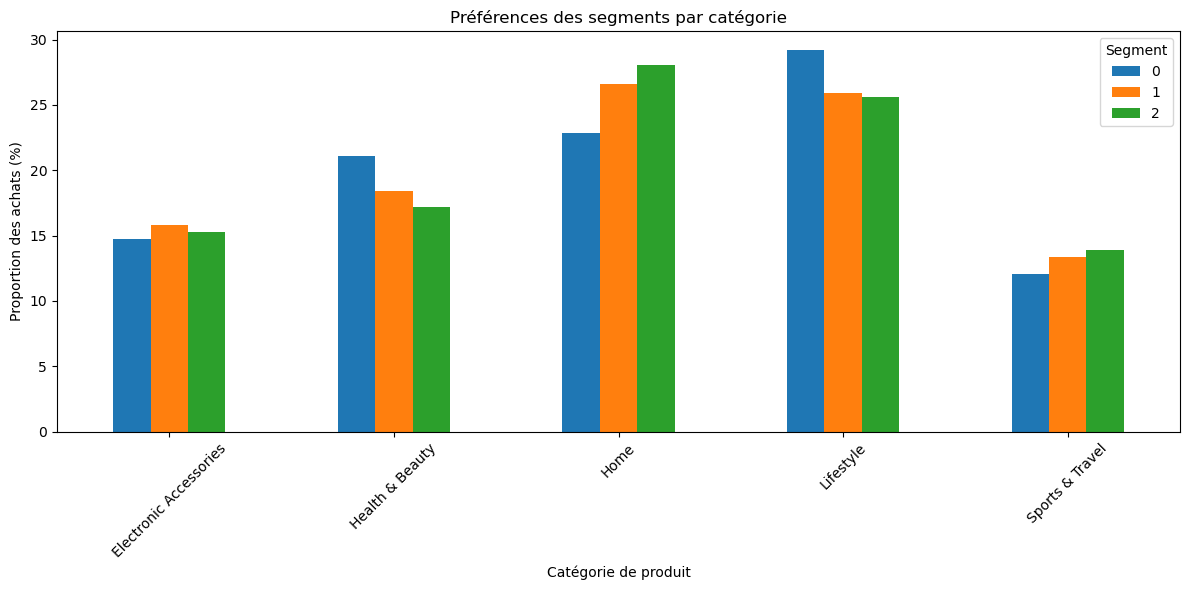

In [39]:
import matplotlib.pyplot as plt

preference_table.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Préférences des segments par catégorie")
plt.xlabel("Catégorie de produit")
plt.ylabel("Proportion des achats (%)")
plt.xticks(rotation=45)
plt.legend(title="Segment")
plt.tight_layout()
plt.show()

### Interprétation des segments

- **Segment 0 – Clients occasionnels :** clients à faible fréquence d’achat et faibles dépenses. Leur catégorie la plus représentée est **Lifestyle (29,17 %)**.
- **Segment 1 – Clients à forte valeur :** clients très actifs, avec les dépenses, la fréquence d’achat et la quantité achetée les plus élevées. Leur catégorie dominante est **Home (26,58 %)**.
- **Segment 2 – Clients réguliers à panier élevé :** clients plus réguliers que le segment 0, avec un **panier moyen élevé**. Leur catégorie dominante est également **Home (28,05 %)**.

**Conclusion :** les segments se distinguent principalement par leur **niveau d’activité et leur valeur d’achat**, tandis que leurs préférences produits restent relativement proches. La catégorie **Home** est particulièrement représentée dans les segments 1 et 2, alors que le segment 0 est davantage orienté vers **Lifestyle**.